    Step 1 → Calculate Prior Probability
         P(Default) = overall default rate

    Step 2 → Calculate Likelihoods
         P(Bad Credit | Default)
         P(High EMI | Default)
         P(Low Income | Default)

    Step 3 → Build Scorer Function
         Input  : applicant's features
         Output : probability of default (0 to 1)

    Step 4 → Score all 6,000 applicants

    Step 5 → Assign Risk Tiers
         🔴 High Risk   > 0.65
         🟡 Medium Risk > 0.35
         🟢 Low Risk   < 0.35

    Step 6 → Validate
         Do High Risk applicants actually default more?
         If yes → model works

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("loan_applicants_clean.csv")
print("Shape:", df.shape)
print("Default Rate:", df["default_status"].mean().round(3))

Shape: (6000, 15)
Default Rate: 0.12


## Step 1: Prior Probability
    In Bayesian thinking, the prior is your starting belief before you know anything specific about an applicant. In this case:
    "What is the probability that ANY random loan applicant defaults?"

In [2]:
# ---- Step 1: Prior Probability ----
# P(Default) = overall default rate in our portfolio

P_default = df["default_status"].mean()
P_no_default = 1 - P_default

print(f"P(Default) = {P_default:.4f} ({P_default*100:.2f}%)")
print(f"P(No Default) = {P_no_default:.4f} ({P_no_default*100:.2f}%)")

P(Default) = 0.1195 (11.95%)
P(No Default) = 0.8805 (88.05%)


## Step 2: Calculate Likelihoods

In [3]:
# ---- Step 2: Calculate Likelihoods ----

# Separate defaulters and non-defaulters
defaulters = df[df["default_status"] == 1]
non_defaulters = df[df["default_status"] == 0]

# ---- Likelihood 1: Credit History ----
# P(Credit History = X | Default) and P(Credit History = X | No Default) 
print("\n--- Credit History Likelihoods ---")
credit_likelihood = df.groupby("credit_history")["default_status"].agg(
    total = "count",
    defaults = sum
)
credit_likelihood["non_defaults"] = credit_likelihood["total"] - credit_likelihood["defaults"]

credit_likelihood["P(Default | Credit)"] = (
    credit_likelihood["defaults"] / credit_likelihood["total"]
).round(4)
credit_likelihood["P(Credit | Default)"] = (
    credit_likelihood["defaults"] / len(defaulters) 
).round(4)
credit_likelihood["P(Credit | No Default)"] = (
    credit_likelihood["non_defaults"] / len(non_defaulters)
).round(4)

credit_likelihood


--- Credit History Likelihoods ---


C:\Users\soumi\AppData\Local\Temp\ipykernel_21928\243159200.py:10: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  credit_likelihood = df.groupby("credit_history")["default_status"].agg(


,total,defaults,non_defaults,P(Default | Credit),P(Credit | Default),P(Credit | No Default)
credit_history,,,,,,
Bad,711,284,427,0.3994,0.3961,0.0808
Good,4720,323,4397,0.0684,0.4505,0.8323
No History,569,110,459,0.1933,0.1534,0.0869


In [4]:
# ---- Likelihood 2: Emi Burden ----
df["emi_burden_category"] = pd.cut(
    df["existing_emi"] / df["applicant_income"],
    bins = [0, 0.15, 0.30, 1.0],
    labels = ["Low", "Medium", "High"]
)

print("\n--- EMI Burden Likelihoods ---")
emi_likelihood = df.groupby("emi_burden_category", observed = True)["default_status"].agg(
    total = "count",
    defaults = "sum"
)
emi_likelihood["non_defaults"] = emi_likelihood["total"] - emi_likelihood["defaults"]

emi_likelihood["P(Default | EMI)"] = (
    emi_likelihood["defaults"] / emi_likelihood["total"]
).round(4)
emi_likelihood["P(EMI | Default)"] = (
    emi_likelihood["defaults"] / len(defaulters)
).round(4)
emi_likelihood["P(EMI | No Default)"] = (
    emi_likelihood["non_defaults"] / len(non_defaulters)
).round(4)

emi_likelihood


--- EMI Burden Likelihoods ---


,total,defaults,non_defaults,P(Default | EMI),P(EMI | Default),P(EMI | No Default)
emi_burden_category,,,,,,
Low,2618,268,2350,0.1024,0.3738,0.4448
Medium,2518,335,2183,0.1330,0.4672,0.4132
High,864,114,750,0.1319,0.1590,0.1420


In [5]:
# ---- Likelihood 3: Income Bracket ----
df ["income_bracket"] = pd.cut (
    df["applicant_income"],
    bins = [0, 35000, 70000, float("inf")],
    labels = ["Low", "Medium", "High"]
)

print("\n--- Income Bracket Likelihoods ---")
income_likelihood = df.groupby("income_bracket", observed = True)["default_status"].agg(
    total = "count",
    defaults = "sum"
)
income_likelihood["non_defaults"] = income_likelihood["total"] - income_likelihood["defaults"]

income_likelihood["P(Default | Income)"] = (
    income_likelihood["defaults"] / income_likelihood["total"]
).round(4)
income_likelihood["P(Income | Default)"] = (
    income_likelihood["defaults"] / len(defaulters)
).round(4)
income_likelihood["P(Income | No Default)"] = (
    income_likelihood["non_defaults"] / len(non_defaulters)
).round(4)

income_likelihood


--- Income Bracket Likelihoods ---


,total,defaults,non_defaults,P(Default | Income),P(Income | Default),P(Income | No Default)
income_bracket,,,,,,
Low,1598,219,1379,0.1370,0.3054,0.2610
Medium,2902,321,2581,0.1106,0.4477,0.4885
High,1500,177,1323,0.1180,0.2469,0.2504


In [6]:
# ---- Step 2: Calculate Likelihoods ----

# Separate defaulters and non-defaulters
defaulters = df[df["default_status"] == 1]
non_defaulters = df[df["default_status"] == 0]

# ---- Likelihood 1: Credit History ----
# P(Credit History = X | Default) and P(Credit History = X | No Default) 
print("\n--- Credit History Likelihoods ---")
credit_likelihood = df.groupby("credit_history")["default_status"].agg(
    total = "count",
    defaults = sum
)
credit_likelihood["non_defaults"] = credit_likelihood["total"] - credit_likelihood["defaults"]

credit_likelihood["P(Default | Credit)"] = (
    credit_likelihood["defaults"] / credit_likelihood["total"]
).round(4)
credit_likelihood["P(Credit | Default)"] = (
    credit_likelihood["defaults"] / len(defaulters) 
).round(4)
credit_likelihood["P(Credit | No Default)"] = (
    credit_likelihood["non_defaults"] / len(non_defaulters)
).round(4)

print(credit_likelihood)

# ---- Likelihood 2: Emi Burden ----
df["emi_burden_category"] = pd.cut(
    df["existing_emi"] / df["applicant_income"],
    bins = [0, 0.15, 0.30, 1.0],
    labels = ["Low", "Medium", "High"]
)

print("\n--- EMI Burden Likelihoods ---")
emi_likelihood = df.groupby("emi_burden_category", observed = True)["default_status"].agg(
    total = "count",
    defaults = "sum"
)
emi_likelihood["non_defaults"] = emi_likelihood["total"] - emi_likelihood["defaults"]

emi_likelihood["P(Default | EMI)"] = (
    emi_likelihood["defaults"] / emi_likelihood["total"]
).round(4)
emi_likelihood["P(EMI | Default)"] = (
    emi_likelihood["defaults"] / len(defaulters)
).round(4)
emi_likelihood["P(EMI | No Default)"] = (
    emi_likelihood["non_defaults"] / len(non_defaulters)
).round(4)

print(emi_likelihood)

# ---- Likelihood 3: Income Bracket ----
df ["income_bracket"] = pd.cut (
    df["applicant_income"],
    bins = [0, 35000, 70000, float("inf")],
    labels = ["Low", "Medium", "High"]
)

print("\n--- Income Bracket Likelihoods ---")
income_likelihood = df.groupby("income_bracket", observed = True)["default_status"].agg(
    total = "count",
    defaults = "sum"
)
income_likelihood["non_defaults"] = income_likelihood["total"] - income_likelihood["defaults"]

income_likelihood["P(Default | Income)"] = (
    income_likelihood["defaults"] / income_likelihood["total"]
).round(4)
income_likelihood["P(Income | Default)"] = (
    income_likelihood["defaults"] / len(defaulters)
).round(4)
income_likelihood["P(Income | No Default)"] = (
    income_likelihood["non_defaults"] / len(non_defaulters)
).round(4)

print(income_likelihood)


--- Credit History Likelihoods ---
                total  defaults  non_defaults  P(Default | Credit)  \
credit_history                                                       
Bad               711       284           427               0.3994   
Good             4720       323          4397               0.0684   
No History        569       110           459               0.1933   

                P(Credit | Default)  P(Credit | No Default)  
credit_history                                               
Bad                          0.3961                  0.0808  
Good                         0.4505                  0.8323  
No History                   0.1534                  0.0869  

--- EMI Burden Likelihoods ---
                     total  defaults  non_defaults  P(Default | EMI)  \
emi_burden_category                                                    
Low                   2618       268          2350            0.1024   
Medium                2518       335          2183     

C:\Users\soumi\AppData\Local\Temp\ipykernel_21928\1563235194.py:10: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  credit_likelihood = df.groupby("credit_history")["default_status"].agg(


### Key takeaways from step 2

##### Credit History — strongest signal:
    Bad credit    → 39.94% default rate  🔴 nearly 4x the baseline
    No History    → 19.33% default rate  🟡 1.6x the baseline  
    Good credit   → 6.84%  default rate  🟢 well below baseline

Bad credit applicants default at 40% — that's 3.3x the portfolio baseline of 11.95%. This is your most powerful feature by far.


##### EMI Burden — weaker than expected:

    Low EMI    → 10.24% default rate    
Medium EMI → 13.30% default rate    
High EMI   → 13.19% default ra

Surprisingly flat across categories — Medium and High are almost identical. This tells us EMI burden alone isn't a strong standalone predictor in our dataset, but it still adds signal when combined with credit history.te

##### Income Bracket — weakest signal:
    Low income    → 13.70% default rate    Medium income → 11.06% default rate    
    
High income   → 11.80% default rtee
Almost no difference across income brackets — barely moves from baseline. Interesting real-world insight: income alone doesn't predict default well. What matters more is the ratio of debt to income, not income in isolation.

Feature importance ranking:
1. Credit History  ← dominant signal (40% vs 7% default rate)
2. EMI Burden      ← moderate signal
3. Income Bracket  ← weak signal

## Step 3: Building the actual scorer function

In [7]:
# ---- Step 3: Build Bayesian Risk Scorer (Corrected) ----

# ---- 3a: The Prior — P(Default) ----
# Baseline probability of default, before knowing anything about the applicant
P_default = len(defaulters) / len(df)
P_no_default = 1 - P_default

print(f"Prior P(Default)    : {P_default:.4f}")
print(f"Prior P(No Default) : {P_no_default:.4f}")

# ---- 3b: Build likelihood dictionaries the CORRECT way ----
# We need P(Feature | Default) AND P(Feature | No Default) for each category
# — not P(Default | Feature).

def build_likelihood_dict(df, feature_col):
    """
    For a given categorical feature column, returns two dictionaries:
    - P(category | Default)     -> how common this category is among defaulters
    - P(category | No Default)  -> how common this category is among non-defaulters
    """
    defaulters_df = df[df["default_status"] == 1]
    non_defaulters_df = df[df["default_status"] == 0]

    p_given_default = (
        defaulters_df[feature_col].value_counts(normalize=True)
    ).to_dict()

    p_given_no_default = (
        non_defaulters_df[feature_col].value_counts(normalize=True)
    ).to_dict()

    return p_given_default, p_given_no_default

# Credit history likelihoods
credit_given_default, credit_given_no_default = build_likelihood_dict(df, "credit_history")

# EMI burden likelihoods (using the bucket column from Step 2)
emi_given_default, emi_given_no_default = build_likelihood_dict(df, "emi_burden_category")

# Income bracket likelihoods (using the bucket column from Step 2)
income_given_default, income_given_no_default = build_likelihood_dict(df, "income_bracket")

print("\nP(Credit | Default):", credit_given_default)
print("P(Credit | No Default):", credit_given_no_default)
print("\nP(EMI | Default):", emi_given_default)
print("P(EMI | No Default):", emi_given_no_default)
print("\nP(Income | Default):", income_given_default)
print("P(Income | No Default):", income_given_no_default)


# ---- 3c: Helper functions to bucket a NEW applicant's raw values ----
def get_emi_category(emi_ratio):
    if emi_ratio <= 0.15:
        return "Low"
    elif emi_ratio <= 0.30:
        return "Medium"
    else:
        return "High"

def get_income_category(income):
    if income <= 35000:
        return "Low"
    elif income <= 70000:
        return "Medium"
    else:
        return "High"


# ---- 3d: The actual Bayesian scoring function ----
def bayesian_risk_score(credit_history, applicant_income, existing_emi):
    """
    Computes probability of default for a loan applicant using Naive Bayes.

    Formula:
        P(Default | Evidence) = [P(Evidence | Default) * P(Default)]
                                 / P(Evidence)

    Where "Evidence" = credit_history AND emi_category AND income_category,
    treated as independent given default status (the "Naive" assumption).

    Parameters:
        credit_history    : 'Good', 'Bad', or 'No History'
        applicant_income  : monthly income in ₹
        existing_emi      : existing monthly EMI in ₹

    Returns:
        risk_score : float between 0 and 1 -> P(Default | this applicant's evidence)
        risk_tier  : 'High Risk', 'Medium Risk', or 'Low Risk'
    """

    # Get feature categories for this new applicant
    emi_ratio  = existing_emi / applicant_income
    emi_cat    = get_emi_category(emi_ratio)
    income_cat = get_income_category(applicant_income)

    # Look up P(Feature | Default) for each feature
    # .get(key, small_number) avoids a crash if a category never appeared
    # among defaulters in the training data (probability effectively ~0)
    p_credit_d = credit_given_default.get(credit_history, 0.0001)
    p_emi_d    = emi_given_default.get(emi_cat, 0.0001)
    p_income_d = income_given_default.get(income_cat, 0.0001)

    # Look up P(Feature | No Default) for each feature
    p_credit_nd = credit_given_no_default.get(credit_history, 0.0001)
    p_emi_nd    = emi_given_no_default.get(emi_cat, 0.0001)
    p_income_nd = income_given_no_default.get(income_cat, 0.0001)

    # Naive Bayes numerator: P(Default) * P(credit|Default) * P(emi|Default) * P(income|Default)
    raw_score = P_default * p_credit_d * p_emi_d * p_income_d

    # Mirror calculation for "No Default" side
    raw_no_default = P_no_default * p_credit_nd * p_emi_nd * p_income_nd

    # Normalize: converts the raw products into a true 0-1 probability
    risk_score = raw_score / (raw_score + raw_no_default)

    # Assign risk tier
    if risk_score >= 0.65:
        risk_tier = "High Risk"
    elif risk_score >= 0.35:
        risk_tier = "Medium Risk"
    else:
        risk_tier = "Low Risk"

    return round(risk_score, 4), risk_tier


# ---- 3e: Quick test — score 3 sample applicants ----
test_cases = [
    ("Bad",        25000, 9000),   # bad credit, low income, high EMI
    ("Good",       80000, 5000),   # good credit, high income, low EMI
    ("No History", 45000, 10000),  # no history, medium income, medium EMI
]

print("\n" + "=" * 60)
print(f"{'Credit':<15} {'Income':>10} {'EMI':>8} {'Score':>8} {'Tier'}")
print("=" * 60)

for credit, income, emi in test_cases:
    score, tier = bayesian_risk_score(credit, income, emi)
    print(f"{credit:<15} ₹{income:>8,} ₹{emi:>6,}   {score:>6}  {tier}")

print("=" * 60)

Prior P(Default)    : 0.1195
Prior P(No Default) : 0.8805

P(Credit | Default): {'Good': 0.4504881450488145, 'Bad': 0.39609483960948394, 'No History': 0.15341701534170155}
P(Credit | No Default): {'Good': 0.8322922581866364, 'No History': 0.0868824531516184, 'Bad': 0.08082528866174522}

P(EMI | Default): {'Medium': 0.46722454672245467, 'Low': 0.3737796373779637, 'High': 0.1589958158995816}
P(EMI | No Default): {'Low': 0.4448230172250615, 'Medium': 0.4132121900435359, 'High': 0.1419647927314026}

P(Income | Default): {'Medium': 0.4476987447698745, 'Low': 0.3054393305439331, 'High': 0.24686192468619247}
P(Income | No Default): {'Medium': 0.4885481733863335, 'Low': 0.26102593223547227, 'High': 0.2504258943781942}

Credit              Income      EMI    Score Tier
Bad             ₹  25,000 ₹ 9,000   0.4657  Medium Risk
Good            ₹  80,000 ₹ 5,000   0.0574  Low Risk
No History      ₹  45,000 ₹10,000   0.1989  Low Risk


In [8]:
# ---- Step 3: Build Bayesian Risk Scorer ----

# ---- 3a: Reuse the Prior from Step 1 ----
# P_defaulte and P_no_default already exist from Step 1 - no need to recompute
print(f"Prior P(Default)    : {P_default}")
print(f"Prior P(No Default) : {P_no_default}")

# ---- 3b: Convert Step 2's likelihood tables into lookup dictionaries ----
# credit_likelihood, emi_likelihood, income_likelihood alreafy have "P(X | Default)" and "P(X | No Default)" columns from Step 2 -
# just covert these columns into dict for fast lookup.

credit_given_default = credit_likelihood["P(Credit | Default)"].to_dict()
credit_given_no_default = credit_likelihood["P(Credit | No Default)"].to_dict()

emi_given_default = emi_likelihood["P(EMI | Default)"].to_dict()
emi_given_no_default = emi_likelihood["P(EMI | No Default)"].to_dict()

income_given_default = income_likelihood["P(Income | Default)"].to_dict()
income_given_no_default = income_likelihood["P(Income | No Default)"].to_dict()

# ---- 3c: Helper functions to bucket a NEW applicant's raw values ----
# Must match the exact bins used in Step 2
def get_emi_category(emi_ratio):
    if emi_ratio <= 0.15:
        return "Low"
    elif emi_ratio <= 0.30:
        return "Medium"
    else:
        return "High"

def get_income_category(income):
    if income <= 35000:
        return "Low"
    elif income <= 70000:
        return "Medium"
    else:
        return "High"

# ---- 3d: The Bayesian Scoring Function ----
def bayesian_risk_score(credit_history, applicant_income, existing_emi):
    """
    Computes probability of default for a loan applicant using Naive Bayes.
    Formula:
    P(Default | Evidence) = [P(Evidence | Default) * P(Default)] / P(Evidence)
    
    Where "Evidence" = credit_history AND emi_category AND income_category, treated as independent given default status (the Naive assumption).

    Parameters:
        credit_history   : 'Good', 'Bad', or 'No History'
        applicant_income : monthly income in ₹
        existing_emi     : existing monthly EMI in ₹

    Returns:
        risk_score : float between 0 and 1 -> P(Default | this applicant's evidence) 
        risk_tier  : 'High Risk', 'Medium Risk', or 'Low Risk'
    """
    
    # Bucket this applicant's raw values into categories
    emi_ratio = existing_emi / applicant_income
    emi_cat = get_emi_category(emi_ratio)
    income_cat = get_income_category(applicant_income)

    # P(Feature | Default) - .get() falls back to a tiny probability if a category was never seen among defaulters, avoiding a KeyError crash.
    p_credit_d = credit_given_default.get(credit_history, 0.0001)
    p_emi_d = emi_given_default.get(emi_cat, 0.0001)
    p_income_d = income_given_default.get(income_cat, 0.0001)

    # P(Feature | No Default)
    p_credit_nd = credit_given_no_default.get(credit_history, 0.0001)
    p_emi_nd = emi_given_no_default.get(emi_cat, 0.0001)
    p_income_nd = income_given_no_default.get(income_cat, 0.0001)

    # Naive Bayes numerators for both hypotheses
    raw_default = P_default * p_credit_d * p_emi_d * p_income_d
    raw_no_default = P_no_default * p_credit_nd * p_emi_nd * p_income_nd

    # Normalize so the result is a true 0-1 probability
    risk_score = raw_default / (raw_default + raw_no_default)

    # Assign risk tier
    if risk_score >= 0.65:
        risk_tier = "High Risk"
    elif risk_score >= 0.35:
        risk_tier = "Medium Risk"
    else:
        risk_tier = "Low Risk"
        
    return round(risk_score, 4), risk_tier

# ---- 3e: Quick test - score 3 sample applicants ----
test_cases = [
    ("Bad", 25000, 9000),        # bad credit, low income, high EMI
    ("Good", 80000, 5000),       # good credit, high income, low EMI
    ("No History", 45000, 10000) # no history, medium income, medium EMI
]

print("\n" + "=" * 60)
print(f"{'Credit':<15} {'Income':>10} {'EMI':>8} {'Score':>8} {'Tier'}")
print("=" * 60)

for credit, income, emi in test_cases:
    score, tier = bayesian_risk_score(credit, income, emi)
    print(f"{credit:<15} ₹{income:>9,} ₹{emi:>7,}  {score:>7}  {tier}")

print("=" * 60)

Prior P(Default)    : 0.1195
Prior P(No Default) : 0.8805000000000001

Credit              Income      EMI    Score Tier
Bad             ₹   25,000 ₹  9,000   0.4657  Medium Risk
Good            ₹   80,000 ₹  5,000   0.0574  Low Risk
No History      ₹   45,000 ₹ 10,000   0.1989  Low Risk


In [9]:
# ---- Step 4: Score All 6,000 Applicants ----

# ---- 4a: Apply the scorer row-by-row across the whole dataframe ----
# df.apply(..., axis=1) runs the function once per row, passing that row's values in as arguments.
# Since bayesian_risk_score() returns a tuple (scorxe, tier), the result is a Series of tuples.

results = df.apply(
    lambda row: bayesian_risk_score(
        row["credit_history"],
        row["applicant_income"],
        row["existing_emi"]
    ),
    axis=1
)

# ---- 4b: Unpack the tuple Series into two separate columns ----
# results is currently a single column of (score, tier) pairs.
# pd.DataFrame(results.tolist(), ...) splits each tuple into its own column.

df[["risk_score", "risk_tier"]] = pd.DataFrame(
    results.tolist(),
    index = df.index
)

# ---- 4c: Quick sanity checks ----
print("Sample of scored Applicants: ")
df[["credit_history", "applicant_income", "existing_emi", "risk_score", "risk_tier", "default_status"]].head(10)

Sample of scored Applicants: 


,credit_history,applicant_income,existing_emi,risk_score,risk_tier,default_status
0,Good,43510.0,767,0.0535,Low Risk,0
1,Good,135336.0,10906,0.0574,Low Risk,0
2,Good,93748.0,423,0.0574,Low Risk,0
3,Good,77999.0,9687,0.0574,Low Risk,0
4,Good,17692.0,4966,0.0886,Low Risk,0
5,Good,89100.0,18451,0.0757,Low Risk,0
6,Good,34221.0,9738,0.0886,Low Risk,0
7,Good,54181.0,2305,0.0535,Low Risk,0
8,No History,65879.0,2994,0.1558,Low Risk,0
9,Good,47798.0,179,0.0535,Low Risk,0


In [10]:
print("Risk score summary statitics:\n")
print(df["risk_score"].describe())

print("\nRisk tier distribution:\n")
print(df["risk_tier"].value_counts())
print("\n")
print(df["risk_tier"].value_counts(normalize=True).round(4) * 100)

Risk score summary statitics:

count    6000.000000
mean        0.119452
std         0.110747
min         0.053500
25%         0.057400
50%         0.070700
75%         0.088600
max         0.468200
Name: risk_score, dtype: float64

Risk tier distribution:

risk_tier
Low Risk       5430
Medium Risk     570
Name: count, dtype: int64


risk_tier
Low Risk       90.5
Medium Risk     9.5
Name: proportion, dtype: float64


In [11]:
# ---- Step 4 (continued): Recalibrate Risk Tiers ----
# Issue: Naive Bayes probability multiplication compresses all scores into a narrow low range (0.05 - 0.47), causing zero High Risk classifications.
# Fix: Use percentile-based thresholds instead of fixed 0.35/0.65 cutoffs so tiers adapt to the actual score distribution.

# Check actual score percentiles
print("Score percentiles:")
print(df["risk_score"].quantile([0.25, 0.50, 0.75, 0.90]).round(4))

# Top 15% = High Risk, next 35% = Medium Risk, bottom 50% = Low Risk
high_threshold   = df["risk_score"].quantile(0.85)
medium_threshold = df["risk_score"].quantile(0.50)

print(f"High Risk Threshold   : {high_threshold:.4f}")
print(f"Medium Risk Threshold : {medium_threshold:.4f}")

# Reassign risk tiers using recalibrated thresholds
def assign_tier(score):
    if score >= high_threshold:
        return "High Risk"
    elif score >= medium_threshold:
        return "Medium Risk"
    else:
        return "Low Risk"

df["risk_tier"] = df["risk_score"].apply(assign_tier)

# New distribution
print("\nNew risk tier distribution:")
print(df["risk_tier"].value_counts())
print("\nProportions (%):")
print((df["risk_tier"].value_counts(normalize=True) * 100).round(1))

# ---- Critical Validation ----
# If High Risk shows highest default rate -> model is working correctly
print("\nDefault rate by risk tier:")
validation = df.groupby("risk_tier")["default_status"].mean() * 100
print(validation.round(2))

Score percentiles:
0.25    0.0574
0.50    0.0707
0.75    0.0886
0.90    0.3388
Name: risk_score, dtype: float64
High Risk Threshold   : 0.1989
Medium Risk Threshold : 0.0707

New risk tier distribution:
risk_tier
Medium Risk    2633
Low Risk       2393
High Risk       974
Name: count, dtype: int64

Proportions (%):
risk_tier
Medium Risk    43.9
Low Risk       39.9
High Risk      16.2
Name: proportion, dtype: float64

Default rate by risk tier:
risk_tier
High Risk      34.70
Low Risk        5.81
Medium Risk     9.12
Name: default_status, dtype: float64


Recalibrated thresholds:
High Risk   : score >= 0.1989
Medium Risk : score >= 0.0707
Low Risk    : score < 0.0707
Mismatches between original tier and re-derived tier: 0

--- Risk Tier Counts ---
risk_tier
Medium Risk    2633
Low Risk       2393
High Risk       974
Name: count, dtype: int64

--- Risk Tier Percentages ---
risk_tier
Medium Risk    43.88
Low Risk       39.88
High Risk      16.23
Name: proportion, dtype: float64

--- Score Range per Tier ---
                min     max    mean  count
risk_tier                                 
High Risk    0.1989  0.4682  0.3500    974
Low Risk     0.0535  0.0701  0.0598   2393
Medium Risk  0.0707  0.1973  0.0884   2633

--- Default rate by Risk tier (VALIDATION) ---
risk_tier
High Risk      34.70
Low Risk        5.81
Medium Risk     9.12
Name: default_status, dtype: float64


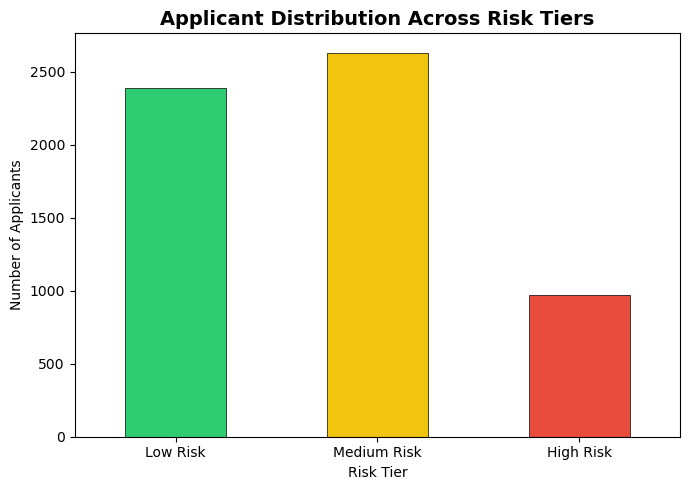

In [12]:
# ---- Step 5: Assign Risk Tiers (Summary and Confirmation)

# ---- Recalibrate thresholds using percentiles ----
# Fixed thresholds (0.35/0.65) produce zero High Risk applicants because Naive Bayes probability multiplication compresses scores 
# into a narrow range (0.05-0.47). Percentile-based thresholds fix this.

high_threshold   = df["risk_score"].quantile(0.85)  # top 15% = High Risk
medium_threshold = df["risk_score"].quantile(0.50)  # next 35% = Medium Risk

print(f"Recalibrated thresholds:")
print(f"High Risk   : score >= {high_threshold:.4f}")
print(f"Medium Risk : score >= {medium_threshold:.4f}")
print(f"Low Risk    : score < {medium_threshold:.4f}")

# ---- 5a: Assign tiers using recalibrated thresholds ----
def assign_tier(score):
    if score >= high_threshold:
        return "High Risk"
    elif score >= medium_threshold:
        return "Medium Risk"
    else:
        return "Low Risk"

df["risk_tier"] = df["risk_score"].apply(assign_tier)

# Safety check: re-derive tier independently and compare
df["risk_tier_check"] = df["risk_score"].apply(assign_tier)
# Compare the two - should be identical everywhere
mismatch_count = (df["risk_tier"] != df["risk_tier_check"]).sum()
print(f"Mismatches between original tier and re-derived tier: {mismatch_count}")
# Drop the check column now that we've confirmed it
df.drop(columns=["risk_tier_check"], inplace=True)

# ---- 5b: Tier distribution summary ----
print("\n--- Risk Tier Counts ---")
tier_counts = df["risk_tier"].value_counts()
print(tier_counts)

print("\n--- Risk Tier Percentages ---")
tier_pct = df["risk_tier"].value_counts(normalize=True).round(4) * 100
print(tier_pct)

# ---- 5c: Risk score range per tier ----
print("\n--- Score Range per Tier ---")
print(df.groupby("risk_tier")["risk_score"].agg(["min", "max", "mean", "count"]).round(4))

# ---- 5d: Critical validation ----
# If High Risk shows highest default rate -> model is validated
print("\n--- Default rate by Risk tier (VALIDATION) ---")
validation = df.groupby("risk_tier")["default_status"].mean() * 100
print(validation.round(2))

# ---- 5e: Visualize tier distribution ----
import matplotlib.pyplot as plt

tier_order = ["Low Risk", "Medium Risk", "High Risk"]
colors = ["#2ecc71", "#f1c40f", "#e74c3c"]

plt.figure(figsize=(7, 5))
df["risk_tier"].value_counts().reindex(tier_order).plot(
    kind="bar", color=colors, edgecolor="black",linewidth=0.5
)
plt.title("Applicant Distribution Across Risk Tiers", fontsize=14, fontweight="bold")
plt.xlabel("Risk Tier")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

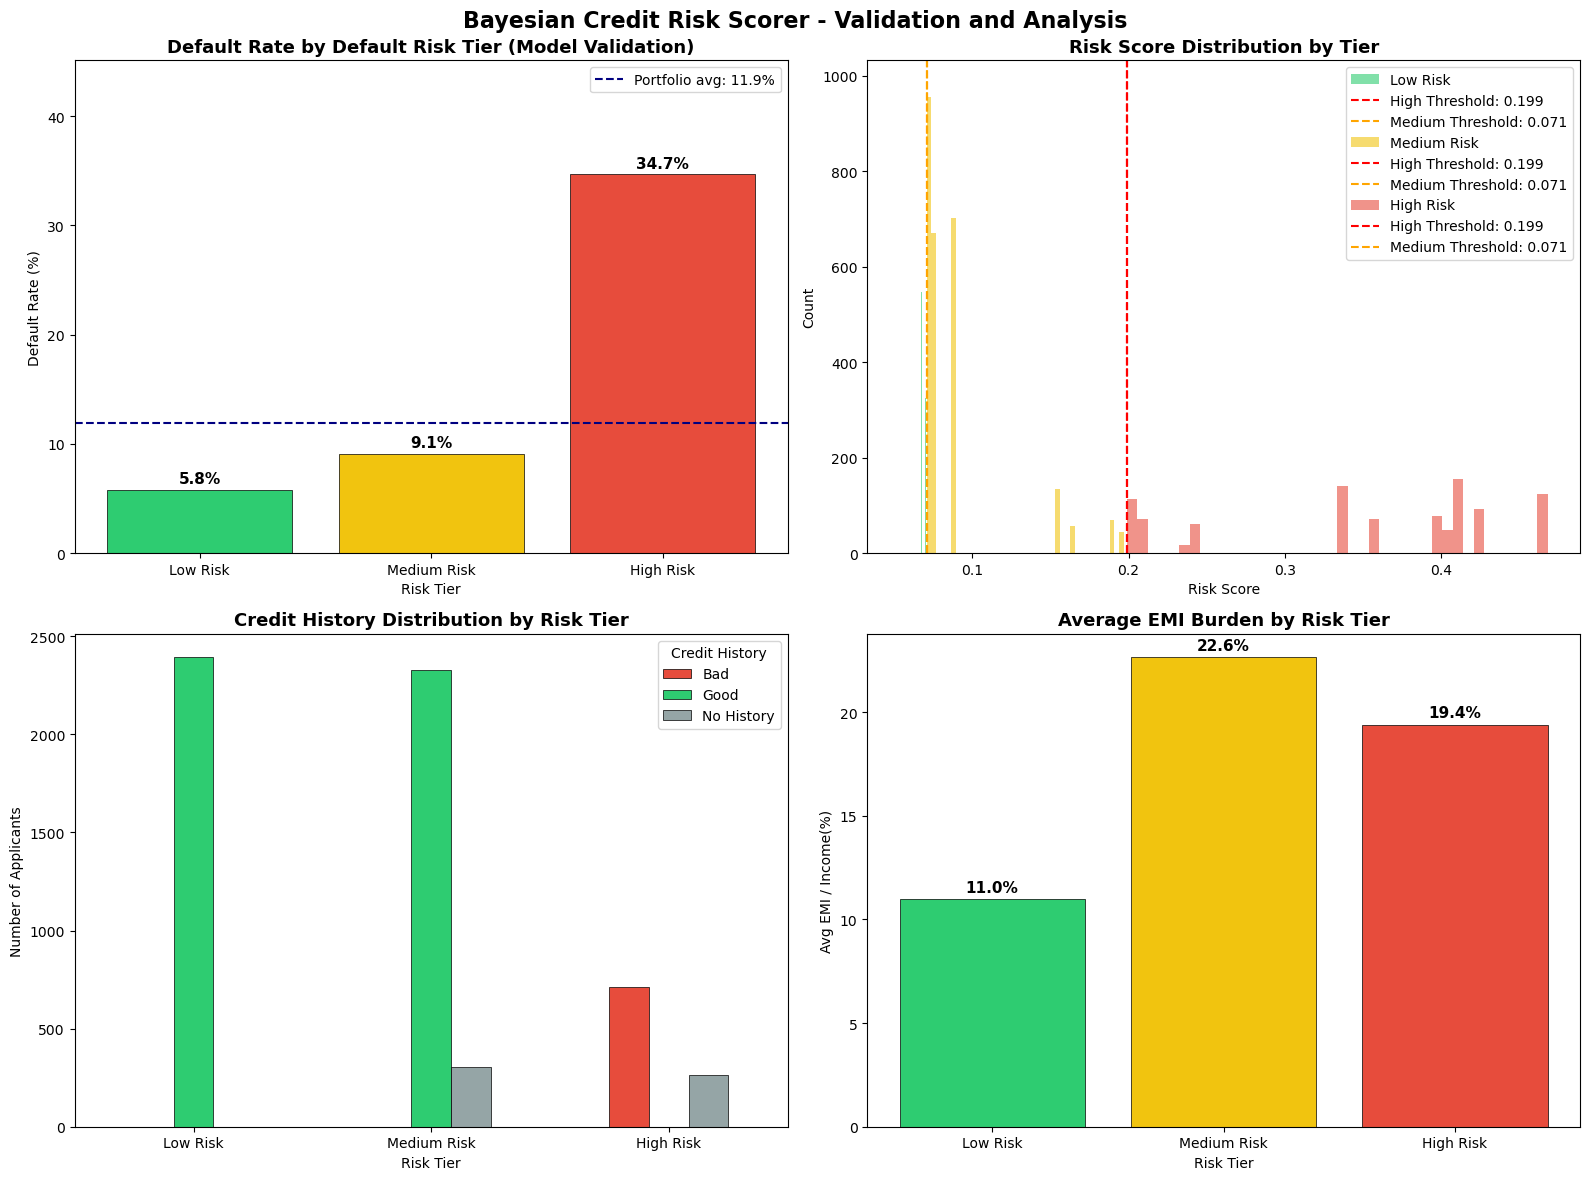


BAYESIAN RISK SCORER - FINAL VALIDATION SUMMARY
             total_applicants  actual_defaults  default_rate_pct  avg_risk_score  avg_emi_burden_pct
risk_tier                                                                                           
Low Risk                 2393              139              5.81          0.0598               10.98
Medium Risk              2633              240              9.12          0.0884               22.65
High Risk                 974              338             34.70          0.3500               19.40
Portfolio Default Rate : 11.95%
High Threshold : 0.1989
Medium Threshold : 0.0707


In [52]:
# ---- Step 6: Validate and Visualize Risk Tiers ----

fig, axes = plt.subplots(2,2, figsize=(16, 12))
fig.suptitle("Bayesian Credit Risk Scorer - Validation and Analysis",
               fontsize=16, fontweight="bold")

tier_order = ["Low Risk", "Medium Risk", "High Risk"]
colors = ["#2ecc71", "#f1c40f", "#e74c3c"]

# ---- Plot 1: Default rate by risk tier (PRIMARY VALIDATION)
# If this shows Low < Medium < High -> model is working

validation = df.groupby("risk_tier")["default_status"].mean() * 100
validation = validation.reindex(tier_order)

bars = axes[0][0].bar(validation.index, validation.values, 
                      color=colors, edgecolor="black", linewidth=0.5)
axes[0][0].set_title("Default Rate by Default Risk Tier (Model Validation)", fontsize=13, fontweight="bold")
axes[0][0].set_xlabel("Risk Tier")
axes[0][0].set_ylabel("Default Rate (%)")
axes[0][0].set_ylim(0, validation.max() * 1.3)
axes[0][0].axhline(y=df["default_status"].mean() * 100,
                   color="navy", linestyle="--", linewidth=1.5,
                   label=f"Portfolio avg: {df["default_status"].mean() * 100:.1f}%")
axes[0][0].legend()
for bar, val in zip(bars, validation.values):
    axes[0][0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height()+0.3,
                    f"{val:.1f}%", ha="center", va="bottom",
                    fontsize=11, fontweight="bold")
    
# ---- Plot 2: Risk score distribution by tier (KDE)

for tier, color in zip(tier_order, colors):
    subset = df[df["risk_tier"] == tier]["risk_score"]
    axes[0][1].hist(subset, bins=40, alpha=0.6,
                   color=color, label=tier, edgecolor="none")
    axes[0][1].set_title("Risk Score Distribution by Tier", fontsize=13, fontweight="bold")
    axes[0][1].set_xlabel("Risk Score")
    axes[0][1].set_ylabel("Count")
    axes[0][1].axvline(high_threshold, color="red",
                       linestyle="--", linewidth=1.5,
                       label=f"High Threshold: {high_threshold:.3f}")
    axes[0][1].axvline(medium_threshold, color="orange",
                       linestyle="--", linewidth=1.5,
                       label=f"Medium Threshold: {medium_threshold:.3f}")
    axes[0][1].legend()

# ---- Plot 3: Credit History distribution by risk tier ----

credit_tier = df.groupby(["risk_tier", "credit_history"],
                         observed=True).size().unstack(fill_value=0)
credit_tier = credit_tier.reindex(tier_order)
credit_tier.plot(kind="bar", ax=axes[1][0], 
                 color=["#e74c3c", "#2ecc71", "#95a5a6"],
                 edgecolor="black", linewidth=0.5)
axes[1][0].set_title("Credit History Distribution by Risk Tier", fontsize=13, fontweight="bold")
axes[1][0].set_xlabel("Risk Tier")
axes[1][0].set_ylabel("Number of Applicants")
axes[1][0].tick_params(axis="x", rotation=0)
axes[1][0].legend(title="Credit History")

# ---- Plot 4: Average EMI burden by risk tier ----

emi_by_tier = df.groupby("risk_tier")["existing_emi"].apply(
    lambda x: (x / df.loc[x.index, "applicant_income"]).mean() * 100
).reindex(tier_order)
bars2 = axes[1][1].bar(emi_by_tier.index, emi_by_tier.values,
                       color=colors, edgecolor="black", linewidth=0.5)
axes[1][1].set_title("Average EMI Burden by Risk Tier", fontsize=13, fontweight="bold")
axes[1][1].set_xlabel("Risk Tier")
axes[1][1].set_ylabel("Avg EMI / Income(%)")
for bar, val in zip(bars2, emi_by_tier.values):
    axes[1][1].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.2,
                    f"{val:.1f}%", ha="center", va="bottom", 
                    fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

# ---- Final Summary Table ----

print("\n" + "="*65)
print("BAYESIAN RISK SCORER - FINAL VALIDATION SUMMARY")
print("="*65)
summary = df.groupby("risk_tier").agg(
    total_applicants   = ("applicant_id", "count"),
    actual_defaults    = ("default_status", "sum"),
    default_rate_pct   = ("default_status", lambda x: round(x.mean()*100, 2)),
    avg_risk_score     = ("risk_score", lambda x: round(x.mean(), 4)),
    avg_emi_burden_pct = ("existing_emi", lambda x: round(
                           (x / df.loc[x.index, "applicant_income"]).mean()*100, 2))
).reindex(tier_order)

print(summary.to_string())
print("="*65)
print(f"Portfolio Default Rate : {df["default_status"].mean()*100:.2f}%")
print(f"High Threshold : {high_threshold:.4f}")
print(f"Medium Threshold : {medium_threshold:.4f}")
print("="*65)